*DATA EXPLORATION*

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
import os
import matplotlib.image as mpimg  
%matplotlib inline

In [143]:
airbnb_data = pd.read_csv('AB_NYC_2019.csv')
airbnb_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
airbnb_data.info()  
# At this stage, I wanted to understand the size and structure of the dataset before doing any cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [58]:
# Check the dataset shape (rows and columns
airbnb_data.shape


(48895, 16)

This dataset has around 49,000 observations in it with 16 columns and it is a mix between categorical and numeric values.

In [59]:
# Identify missing values for each column
airbnb_data.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

 We do already see some missing values, which will require cleaning and handling of NaN values. Later, we may need to continue with mapping certain values to ones and zeros for predictive analytics.

In [ ]:
# Display summary statistics for numerical columns
airbnb_data.describe()  

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


I noticed reviews_per_month has missing values since its count is lower than other columns

The average Airbnb price is around $152 per night

Price has high variability, meaning listings range widely from cheap to very expensive

There are listings with price = 0, which is not realistic and indicates invalid or missing data

There are extreme outliers in price, going up to $10,000(so tht is why we will do iqr)

*DATA CLEANING*

In [144]:
# Handle missing values. instead of dropping rows with missing values, I decided to fill them based on the context of each column:

airbnb_data['name'] = airbnb_data['name'].fillna('Unknown')

airbnb_data['host_name'] = airbnb_data.groupby('host_id')['host_name'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

airbnb_data['last_review'] = airbnb_data['last_review'].fillna('no_review')

airbnb_data['reviews_per_month'] = airbnb_data['reviews_per_month'].fillna(0)



After exploring the data, I handled missing values column by column. For listing names, I replaced missing values with ‘Unknown’. For host names, I filled missing values using the most common name for the same host ID when possible, otherwise 'unknown'. I replaced missing review dates with ‘no_review’, and for reviews_per_month, I used 0 because no value there usually means there were no monthly reviews recorded.

In [145]:
airbnb_data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [146]:
# Verify that numerical columns contain valid values.price <= 0: set as NaN and filled with median grouped by (neighbourhood, room_type).
airbnb_data['price'] = airbnb_data['price'].apply(lambda x: np.nan if x <= 0 else x)
airbnb_data['price'] = airbnb_data.groupby(['neighbourhood', 'room_type'])['price'].transform(lambda x: x.fillna(x.median()))

I verified that important numerical columns contain valid values. For example, a listing price should not be zero or negative, so I treated those as invalid values. Then I filled them using the median price of similar listings based on neighbourhood and room type (I used grouped medians because Airbnb prices depend heavily on both location and room type, so that gives a more realistic replacement value)

In [147]:
airbnb_data[airbnb_data['minimum_nights']<=0]
airbnb_data[airbnb_data['calculated_host_listings_count']<=0]
airbnb_data[airbnb_data['availability_365']<0]


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


since these columns' minimum values should always be a positive number that's why i also checked for these ones(minimum_nights, calculated_host_listings_count, availability_365) and there are no invalid values in these columns.   

In [148]:
# Remove duplicate rows.

print(f'Duplicates: {airbnb_data.duplicated().sum()}')

# and since the result was zero, it means there were no duplicate records in the dataset. Therefore, no removal was necessary

Duplicates: 0


In [149]:
# Convert data types for categorical columns to optimize memory usage.(they are categorical, repetitive, and not meant for numerical calculations)
airbnb_data['neighbourhood_group'] = airbnb_data['neighbourhood_group'].astype('category')
airbnb_data['neighbourhood']       = airbnb_data['neighbourhood'].astype('category')
airbnb_data['room_type']           = airbnb_data['room_type'].astype('category')

I converted categorical columns such as neighbourhood group, neighbourhood, and room type into the category data type to improve memory efficiency and optimize group-based analysis, since these columns contain repeated labels with a limited number of unique values

In [150]:
#Drop columns that provide no analytical value.
airbnb_data.drop(['id', 'name'], axis=1, inplace=True)

contains unstructured text and does not contribute to numerical or categorical analysis

In [151]:
airbnb_data.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   host_id                         48895 non-null  int64   
 1   host_name                       48895 non-null  object  
 2   neighbourhood_group             48895 non-null  category
 3   neighbourhood                   48895 non-null  category
 4   latitude                        48895 non-null  float64 
 5   longitude                       48895 non-null  float64 
 6   room_type                       48895 non-null  category
 7   price                           48895 non-null  float64 
 8   minimum_nights                  48895 non-null  int64   
 9   number_of_reviews               48895 non-null  int64   
 10  last_review                     48895 non-null  object  
 11  reviews_per_month               48895 non-null  float64 
 12  calculated_host_li

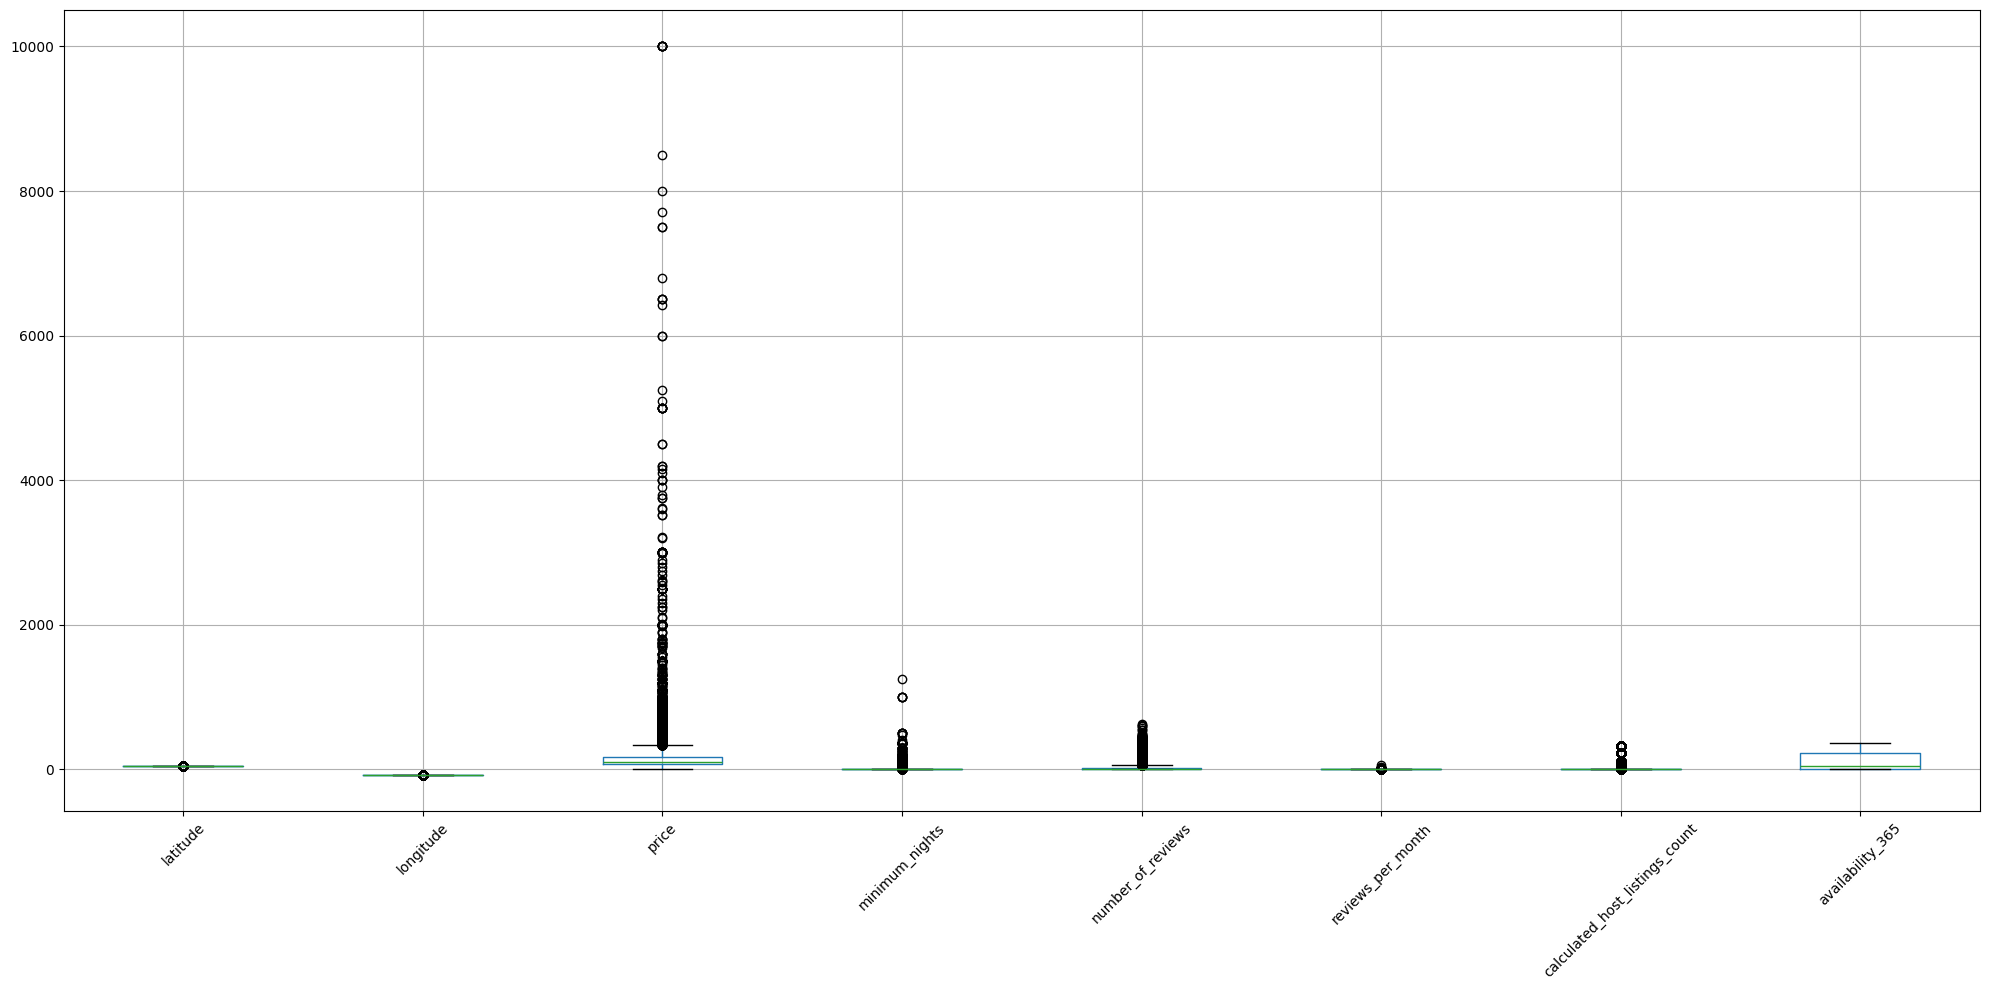

In [152]:
# Outlier detection
airbnb_data_numeric_cols=airbnb_data[['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']]
airbnb_data_numeric_cols.boxplot(figsize=(20, 10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from the boxxplot, I observed that the price column contains extreme outliers reaching up to 10000, which are not representative of typical listings. since price is a key variable in the analysis, I'll apply IQR-based outlier removal specifically to this column
there aare some high values in minimum_nights, number_of_reviews- but these are realistic values(someone can stay 365 nights,listing can have 600 reviews)

In [153]:
# Step 1: Calculate Q1, Q3, and IQR for 'price'
Q1 = airbnb_data['price'].quantile(0.25)
Q3 = airbnb_data['price'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 69.0
Q3: 175.0
IQR: 106.0


In [154]:
# Step 2: Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -90.0
Upper Limit: 334.0


In [155]:
# Step 3: Remove outliers
airbnb_data = airbnb_data[(airbnb_data['price'] >= lower_limit) & (airbnb_data['price'] <= upper_limit)]

print("After removing outliers, remaining rows:", airbnb_data.shape)

After removing outliers, remaining rows: (45923, 14)


I calculated the first quartile, third quaartile, and interquartile range, theen kept only the rows within the acceptable range

In [156]:
# Exported the cleaned dataset to a new CSV file 
airbnb_data.to_csv('AB_NYC_2019_cleaned.csv', index=False)
print('Saved → AB_NYC_2019_cleaned.csv')

Saved → AB_NYC_2019_cleaned.csv


*Data Analysis*

_Average price by neighbourhood group_


In [157]:
avg_price_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
)

print(avg_price_neighbourhood)

  neighbourhood_group   avg_price
2           Manhattan  145.963088
1            Brooklyn  105.731290
4       Staten Island   89.235616
3              Queens   88.904437
0               Bronx   77.433178


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\855157562.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")["price"]


Grouped all listings based on their neighbourhood group and focus on their prices, then calculate the average price for each neighbourhood group and sort them in descending order to identify which neighbourhood group has the highest average price.


_Average price by room type_

In [158]:
avg_price_room_type = (
    airbnb_data.groupby("room_type")["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
)

print(avg_price_room_type)

         room_type   avg_price
0  Entire home/apt  162.543552
1     Private room   79.038621
2      Shared room   59.355009


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3618589076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["price"]


Grouped all listings based on their room type and focused on their prices, then calculated the average price for each room type and sorted them in descending order to identify which room type has the highest average price.


_Median price by neighbourhood group_

In [159]:
median_price_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .median()
    .reset_index(name="median_price")
    .sort_values(by="median_price", ascending=False)
)

print(median_price_neighbourhood)

  neighbourhood_group  median_price
2           Manhattan         135.0
1            Brooklyn          90.0
4       Staten Island          75.0
3              Queens          74.0
0               Bronx          65.0


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\2755385254.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")["price"]


Grouped all listings based on their neighbourhood group and focused on their prices, then calculated the median price for each neighbourhood group and sorted them in descending order to identify which neighbourhood group has the highest median price.


_Minimum and maximum price_

In [160]:
min_price = airbnb_data["price"].min()
max_price = airbnb_data["price"].max()

print("Minimum price:", min_price)
print("Maximum price:", max_price)

Minimum price: 10.0
Maximum price: 334.0


Since we filled '0' prices with medians before, the minimum value is nolonger zero

_Price range for each room type_

In [161]:
price_range_room_type = (
    airbnb_data.groupby("room_type")["price"]
    .agg(min_price="min", max_price="max")
    .reset_index()
)

print(price_range_room_type)

         room_type  min_price  max_price
0  Entire home/apt       10.0      334.0
1     Private room       10.0      333.0
2      Shared room       10.0      320.0


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\308203120.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["price"]


Grouped all listings based on room type and analyze their prices. for each room type, I calculated both the minimum and maximum listing prices(to do it in once i used .agg) then converted the grouped result into a structured table

_Top 10 hosts with the most listings_

In [ ]:
top_hosts_listings = (
    airbnb_data.groupby(["host_id", "host_name"])
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
    .head(10)
)

print(top_hosts_listings )


         host_id          host_name  listing_count
32899  219517861       Sonder (NYC)            272
27974  107434423         Blueground            180
29565  137358866             Kazuya            103
18585   30283594               Kara             95
12126   12243051             Sonder             95
24407   61391963  Corporate Housing             91
13681   16098958     Jeremy & Laura             90
16229   22541573                Ken             87
9253     7503643               Vida             52
2904     1475015               Mike             52


Grouped all listings based on host id and host name, then counted the number of listings for each host, sorted them in descending order, and selected the top 10 hosts with the most listings.

_Average price of listings per host_

In [ ]:
avg_price_per_host = (
    airbnb_data.groupby(["host_id", "host_name"])["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(avg_price_per_host.head())

   host_id host_name   avg_price
0     2438     Tasos   95.000000
1     2571     Teedo  182.000000
2     2787      John  100.666667
3     2845  Jennifer  162.000000
4     2868  Letha M.   60.000000


Grouped data based on host_id and host_name, calculated the mean price for each host, and printed the first 5 rows to see the average price for those hosts.

_Hosts with the highest average listing price_

In [ ]:
top_hosts_avg_price = (
    airbnb_data.groupby(["host_id", "host_name"])["price"]
    .mean()
    .reset_index(name="avg_price")
    .sort_values(by="avg_price", ascending=False)
    .head(10)
)

print(top_hosts_avg_price)

         host_id         host_name  avg_price
1147      412783              Nick      334.0
7085     4876826              Alex      333.0
19870   35635299               Mel      333.0
35126  269146714           Clinton      333.0
18330   29065752            Cullen      333.0
30323  152747338             Paola      333.0
495       148108            Fatima      333.0
24467   62031986              Adam      333.0
33121  224001464           Aleszea      333.0
31643  184520918  Danilo & Larissa      332.0


Grouped all listings based on their room type and focused on their prices, then calculated the average price for each room type and sorted them in descending order to identify which room type has the highest average price.


_Average availability by room type_

In [169]:
avg_availability_room = (
    airbnb_data.groupby("room_type")["availability_365"]
    .mean()
    .reset_index(name="avg_availability")
)

print(avg_availability_room)


         room_type  avg_availability
0  Entire home/apt        106.119400
1     Private room        109.978542
2      Shared room        163.053603


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3690373810.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["availability_365"]


Grouped all listings based on their room type and focused on availability, then calculated the average availability for each room type and sorted them in descending order to identify which room type has the highest average availability.

_Distribution of availability_365_

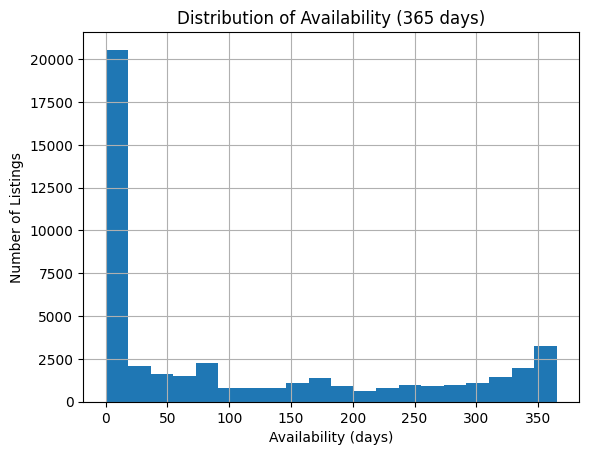

Very low availability listings: 21788
High availability listings: 7307


In [172]:
plt.figure()
airbnb_data["availability_365"].hist(bins=20)

plt.title("Distribution of Availability (365 days)")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Listings")

plt.show()


low_availability = airbnb_data[airbnb_data["availability_365"] < 30]
high_availability = airbnb_data[airbnb_data["availability_365"] > 300]

print("Very low availability listings:", len(low_availability))
print("High availability listings:", len(high_availability))

The histogram shows that a large number of listings have very low availability, indicating either high demand or limited host availability. At the same time, some listings are available throughout the year, suggesting lower occupancy or continuous availability. This highlights variability in listing usage and booking patterns

In [ ]:
# so we saw that there are 21788 listings with very low availability (less than 30 days) and 7307 listings with high availability (more than 300 days). There is a wide variation in availability, indicating different hosting strategies and listing types.

_Listings with very low availability vs high availability_

In [176]:
print("Low availability listings:", len(low_availability))
print("High availability listings:", len(high_availability))

print("Average price (low availability):", low_availability["price"].mean())
print("Average price (high availability):", high_availability["price"].mean())

print("Average reviews (low availability):", low_availability["number_of_reviews"].mean())
print("Average reviews (high availability):", high_availability["number_of_reviews"].mean())

Low availability listings: 21788
High availability listings: 7307
Average price (low availability): 116.13557921791812
Average price (high availability): 124.38428903790886
Average reviews (low availability): 12.080640719662199
Average reviews (high availability): 25.405775283974272


In [ ]:
comparison_df = pd.DataFrame({
    "Group": ["Low Availability", "High Availability"],
    "Listing Count": [len(low_availability), len(high_availability)],
    "Avg Reviews": [
        low_availability["number_of_reviews"].mean(),
        high_availability["number_of_reviews"].mean()
    ]
})

print(comparison_df)

               Group  Listing Count  Avg Reviews
0   Low Availability          21788    12.080641
1  High Availability           7307    25.405775


There are significantly more low-availability listings than high-availability ones.

Listings with high availability tend to have more reviews

High-availability listings have more reviews, likely because they are available longer, while price differences between the groups are minima

_Number of listings by neighbourhood group_

In [177]:
listings_by_neighbourhood_group = (
    airbnb_data.groupby("neighbourhood_group")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_by_neighbourhood_group)
# grouped by neighbourhood group, counted listings, and sorted by count to see which areas have the most listings.

  neighbourhood_group  listing_count
2           Manhattan          19506
1            Brooklyn          19415
3              Queens           5567
0               Bronx           1070
4       Staten Island            365


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\217176649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")


_Number of listings by room type_

In [178]:
listings_by_room_type = (
    airbnb_data.groupby("room_type")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_by_room_type)
# grouped by room type, counted listings, and sorted by count to see which types of accommodations are most common.

         room_type  listing_count
0  Entire home/apt          22789
1     Private room          21996
2      Shared room           1138


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3237483309.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")


_Number of listings per neighbourhood_

In [179]:
listings_per_neighbourhood = (
    airbnb_data.groupby("neighbourhood")
    .size()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(listings_per_neighbourhood.head(10)) 
# grouped by neighbourhood, counted listings, and sorted by count to see which specific areas have the most listings.

          neighbourhood  listing_count
214        Williamsburg           3732
13   Bedford-Stuyvesant           3638
94               Harlem           2585
28             Bushwick           2438
202     Upper West Side           1788
95       Hell's Kitchen           1731
64         East Village           1714
201     Upper East Side           1670
51        Crown Heights           1519
127             Midtown           1144


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\3005123371.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood")


_Compare prices across room types_

In [180]:
price_by_room = (
    airbnb_data.groupby("room_type")["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(price_by_room)
# grouped by room type, calculated average price, and sorted by average price to see which types of accommodations are more expensive on average.

         room_type   avg_price
0  Entire home/apt  162.543552
1     Private room   79.038621
2      Shared room   59.355009


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\630949659.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("room_type")["price"]


_Compare prices across neighbourhood groups_

In [181]:
price_by_neighbourhood = (
    airbnb_data.groupby("neighbourhood_group")["price"]
    .mean()
    .reset_index(name="avg_price")
)

print(price_by_neighbourhood)
# grouped by neighbourhood group, calculated average price, and sorted by average price to see which areas are more expensive on average.

  neighbourhood_group   avg_price
0               Bronx   77.433178
1            Brooklyn  105.731290
2           Manhattan  145.963088
3              Queens   88.904437
4       Staten Island   89.235616


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\2842259479.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood_group")["price"]


_Analyze whether availability_365 relates to price_

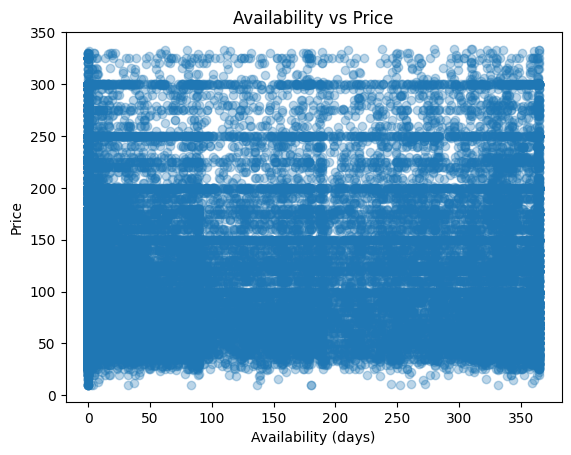

Correlation (availability vs price): 0.06657348828314388


In [ ]:
plt.figure()
plt.scatter(airbnb_data["availability_365"], airbnb_data["price"], alpha=0.3)
plt.title("Availability vs Price")
plt.xlabel("Availability (days)")
plt.ylabel("Price")

plt.show()

corr_availability_price = airbnb_data["availability_365"].corr(airbnb_data["price"])
print("Correlation (availability vs price):", corr_availability_price)


The correlation coefficient is approximately 0.06, which indicates a very weak positive correlation between availability and price. This suggests that there is no strong relationship between how often a listing is available and its price, meaning that other factors likely play a more significant role in determining the price of a listing.

_Analyze whether number_of_reviews relates to price_

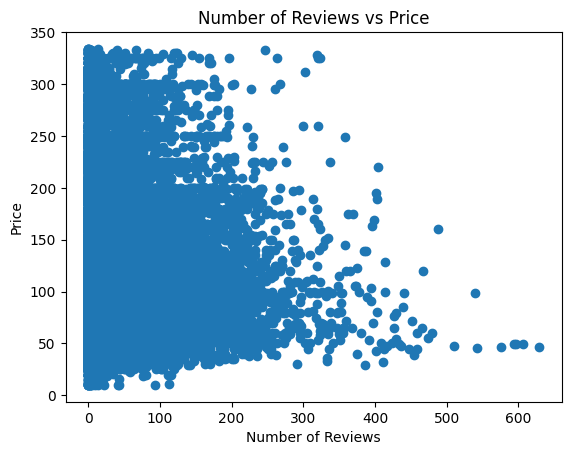

Correlation (reviews vs price): -0.02768039934976301


In [ ]:
plt.figure()
plt.scatter(airbnb_data["number_of_reviews"], airbnb_data["price"])

plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()
corr_reviews_price = airbnb_data["number_of_reviews"].corr(airbnb_data["price"])
print("Correlation (reviews vs price):", corr_reviews_price)



the correlation between number of reviews and price is -0.027, which indicates a very weak negative correlation. This suggests that there is essentially no relationship between the number of reviews a listing has and its price. In other words, having more reviews does not necessarily mean a listing is more expensive or cheaper. 

*Correlation Analysis*

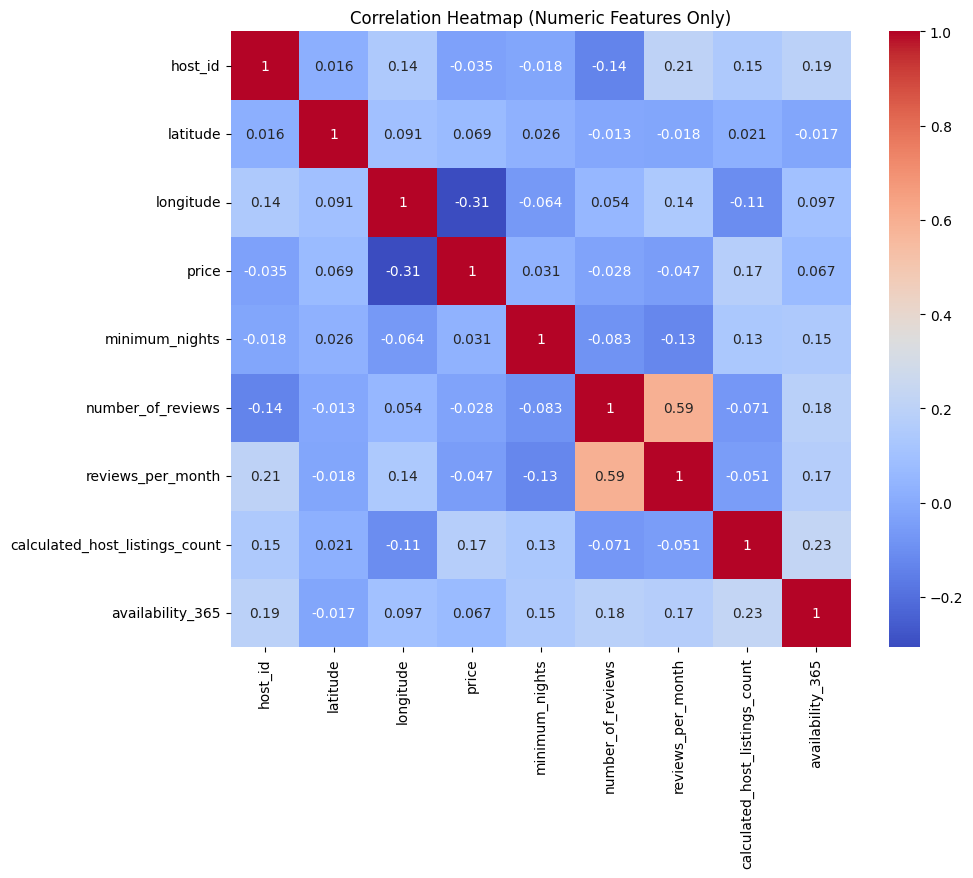

In [ ]:
# Selecting only numeric columns
numeric_df = airbnb_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [186]:
corr = airbnb_data[['price','number_of_reviews','reviews_per_month','availability_365','minimum_nights']].corr(numeric_only=True)
display(corr)

,price,number_of_reviews,reviews_per_month,availability_365,minimum_nights
price,1.000000,-0.027680,-0.047383,0.066573,0.031434
number_of_reviews,-0.027680,1.000000,0.593843,0.183614,-0.082899
reviews_per_month,-0.047383,0.593843,1.000000,0.171457,-0.127805
availability_365,0.066573,0.183614,0.171457,1.000000,0.146457
minimum_nights,0.031434,-0.082899,-0.127805,0.146457,1.000000


heatmap shows that most numerical variables have weak relationships with each other. The strongest correlation is between number of reviews and reviews per month, which is expected since both measure listing popularity. Price does not show strong correlation with other numerical features, suggesting that it is influenced more by categorical variables such as location and room type rather than numerical ones


*Geographic Analysis*

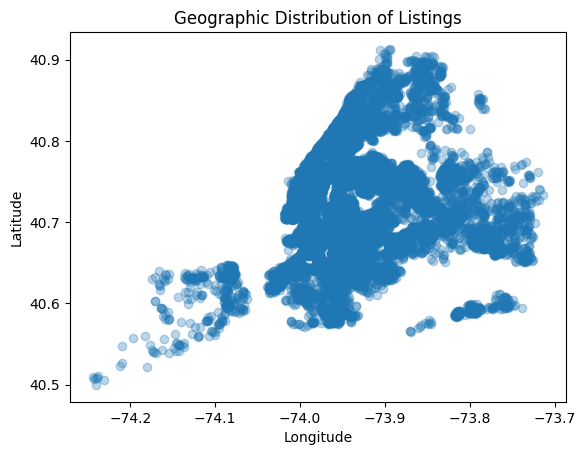

In [101]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(airbnb_data["longitude"], airbnb_data["latitude"], alpha=0.3)

plt.title("Geographic Distribution of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

scatter plot shows that Airbnb listings are heavily concentrated in central areas of New York City, particularly Manhattan and Brooklyn. the distribution is not uniform, with fewer listings in outer boroughs like Staten Island and the Bronx. this indicates that listing density is higher in areas with greater demand and tourism activity

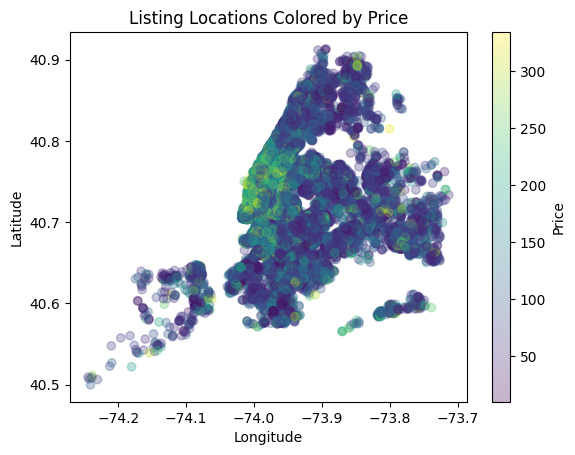

In [ ]:
#Color points by price
plt.figure()
plt.scatter(
    airbnb_data["longitude"],
    airbnb_data["latitude"],
    c=airbnb_data["price"],   
    alpha=0.3
)

plt.colorbar(label="Price")

plt.title("Listing Locations Colored by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

this shows that higher-priced listings are concentrated in central areas of the city, particularly Manhattan, indicating that location strongly influences pricing. however, there is still variation within regions, suggesting that other factors such as room type and listing features also impact price

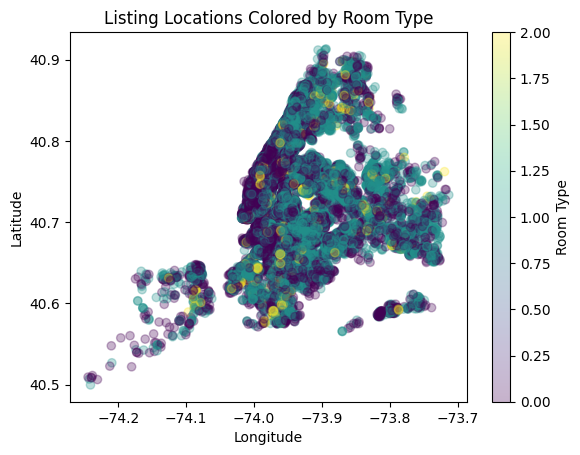

In [ ]:
# Color points by room type
plt.figure()
plt.scatter(
    airbnb_data["longitude"],
    airbnb_data["latitude"],
    c=airbnb_data["room_type"].cat.codes,   
    alpha=0.3
)

plt.colorbar(label="Room Type")
plt.title("Listing Locations Colored by Room Type")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

it shows that different types of listings are available across the city, but central areas such as Manhattan and Brooklyn have a higher density and greater diversity of room types

In [ ]:
top_areas = (
    airbnb_data.groupby("neighbourhood")["id"]
    .count()
    .reset_index(name="listing_count")
    .sort_values(by="listing_count", ascending=False)
)

print(top_areas.head(10))
#  grouped by neighbourhood, counted listings, and sorted by count to see which specific areas have the most listings

          neighbourhood  listing_count
214        Williamsburg           3732
13   Bedford-Stuyvesant           3638
94               Harlem           2585
28             Bushwick           2438
202     Upper West Side           1788
95       Hell's Kitchen           1731
64         East Village           1714
201     Upper East Side           1670
51        Crown Heights           1519
127             Midtown           1144


C:\Users\Ulkar\AppData\Local\Temp\ipykernel_10708\710510392.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airbnb_data.groupby("neighbourhood")["id"]


we see that Williamsburg has the highest number of listings, followed by Bedford-Stuyvesant and Harlem. many of the top neighbourhoods are located in Brooklyn and Manhattan

*Data Visualization*

_Average Price by Neighbourhood Group_

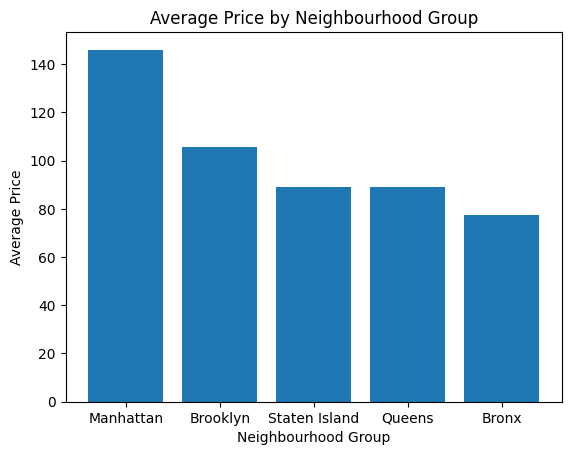

In [112]:
plt.figure()

plt.bar(
    avg_price_neighbourhood["neighbourhood_group"],
    avg_price_neighbourhood["avg_price"]
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")

plt.show()

This chart shows that Manhattan has the highest average price, followed by Brooklyn, while the Bronx has the lowest(Location is one of the strongest factors affecting price)

_Listings by Room Type_


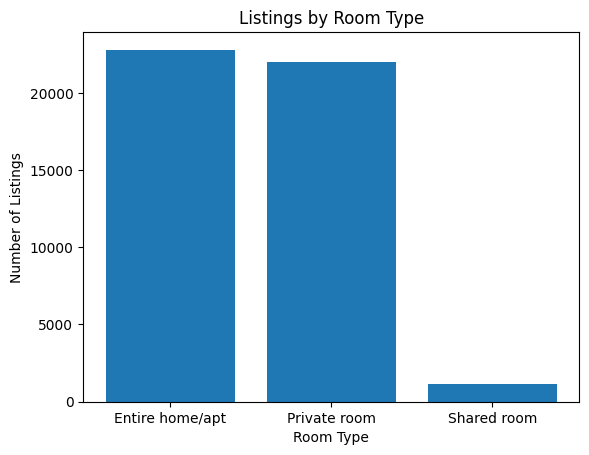

In [114]:
plt.figure()

plt.bar(
    listings_by_room_type["room_type"],
    listings_by_room_type["listing_count"]
)

plt.title("Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

The chart shows that entire home or apartment listings indicates a strong preference for privacy. Private rooms are also common, offering a more affordable option, while shared rooms represent only a small fraction of listings, suggesting lower demand for shared accommodations.(Users prefer privacy → entire homes dominate)

_Price Distribution_

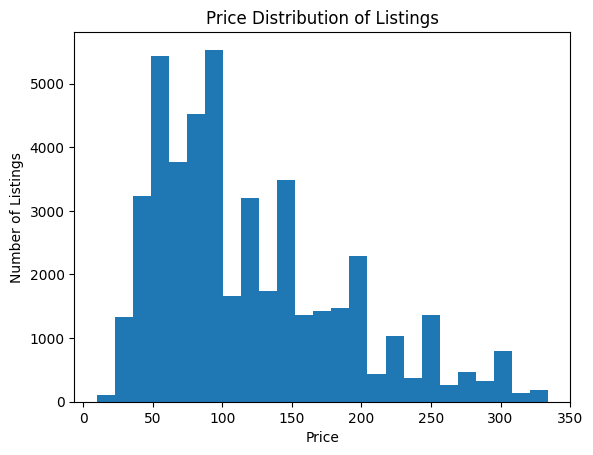

In [187]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(airbnb_data["price"], bins=25)

plt.title("Price Distribution of Listings")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.show()

the price distribution is right-skewed, with the majority of listings concentrated in the lower price range, particularly between $50 and $100. As prices increase, the number of listings decreases, with only a small number of high-priced listings forming a long tail. This indicates that most Airbnb listings are relatively affordable, while premium listings are less common(Airbnb market is: dominated by mid-range affordable listings)

_Availability Distribution_

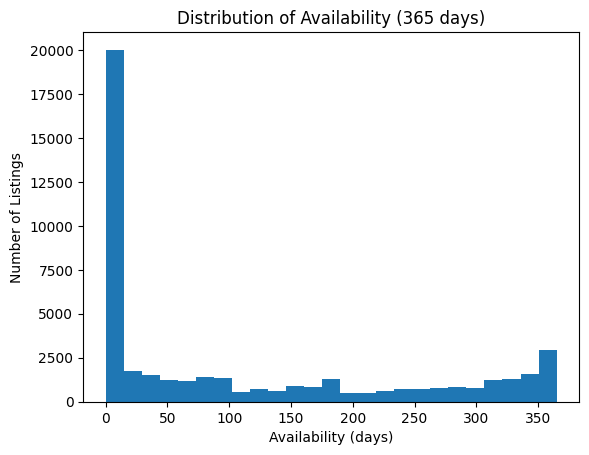

In [188]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(airbnb_data["availability_365"], bins=25)

plt.title("Distribution of Availability (365 days)")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Listings")

plt.show()

the distribution of availability is highly skewed, with a large number of listings having very low availability, suggesting high demand or limited host availability. There is also a smaller group of listings available for most of the year, indicating different hosting strategies or lower occupancy(some operate occasionally, while others keep listings available year-round)

_Top Hosts_

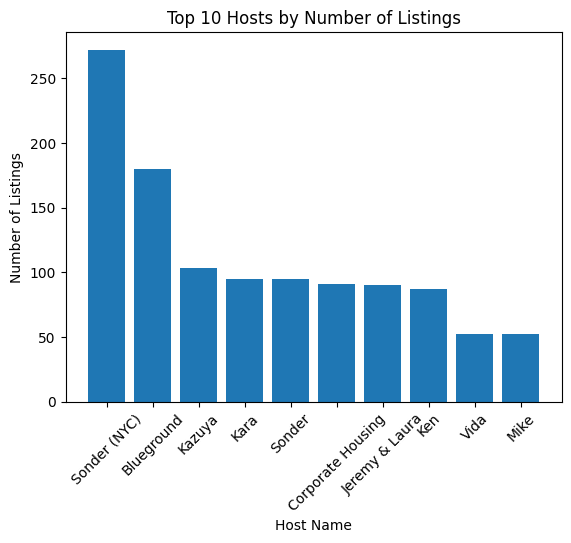

In [ ]:
plt.figure()

plt.bar(
    top_hosts_listings ["host_name"],
    top_hosts_listings["listing_count"]
)

plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45) 

plt.show()

The chart shows that a small number of hosts dominate the Airbnb market by managing a large number of listings, with Sonder and Blueground leading significantly(Airbnb is not only individuals: some hosts operate at large scale)

Correlation Heatmap


                      price  number_of_reviews  reviews_per_month  \
price              1.000000          -0.027680          -0.047383   
number_of_reviews -0.027680           1.000000           0.593843   
reviews_per_month -0.047383           0.593843           1.000000   
availability_365   0.066573           0.183614           0.171457   
minimum_nights     0.031434          -0.082899          -0.127805   

                   availability_365  minimum_nights  
price                      0.066573        0.031434  
number_of_reviews          0.183614       -0.082899  
reviews_per_month          0.171457       -0.127805  
availability_365           1.000000        0.146457  
minimum_nights             0.146457        1.000000  


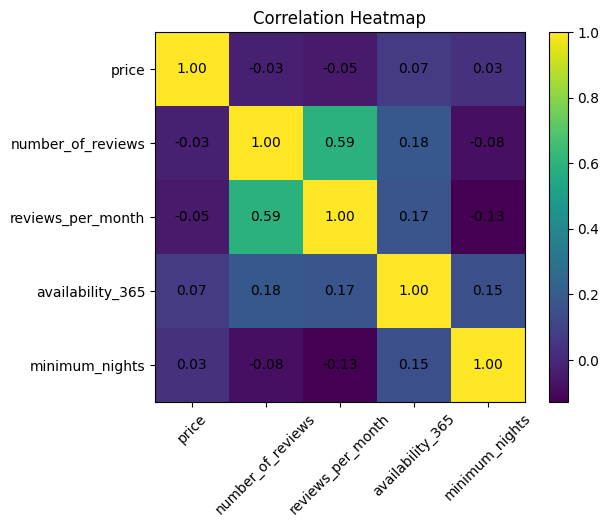

In [ ]:
numeric_cols = [
    "price",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "minimum_nights"
]

corr_matrix = airbnb_data[numeric_cols].corr()
print(corr_matrix)


plt.figure()

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Heatmap")



plt.show()